## Gemma 4 Good Hackathon Submission Notebook

This notebook demonstrates an end-to-end maritime oil-spill workflow using local Sentinel-1 samples, AMSA AIS archives, HYCOM drift context, and Gemma via Ollama for executive-summary generation.

### Notebook Overview

- Select a Sentinel-1 sample image and classify oil vs no-oil.
- If oil is detected, generate a 2022 spill scenario, estimate origin and +24h forecast drift, and evaluate coastline priority using MARPOL-informed thresholds (50 NM tanker context, 12 NM non-tanker context).
- Rank nearby vessels from AMSA AIS archives and render map overlays for spill markers, drift vectors, and vessel track context.
- Build structured case facts and pass them to Gemma (through Ollama) to produce a markdown executive summary.

### How To Read The Output

- The map image shows inferred origin, current slick location, forecast location, and vessel context.
- The executive summary is generated by Gemma/Ollama in markdown format.
- If Earth Engine is unavailable, scenario generation can switch to deterministic fallback behavior.
- If Ollama or the selected Gemma model is unavailable, the summary step raises a clear runtime error so the issue is visible immediately.

In [1]:
from pathlib import Path
import io
import json
import math
import os
import random
import re
import sys
import zipfile

import pandas as pd
import torch
import timm
from IPython.display import Markdown, display
from PIL import Image
from torchvision import transforms
import torch.nn.functional as F

IN_KAGGLE = bool(os.environ.get('KAGGLE_KERNEL_RUN_TYPE') or os.environ.get('KAGGLE_URL_BASE'))
REPO_ROOT = Path.cwd() if (Path.cwd() / 'best_models').exists() else Path.cwd() / 'gemma-oil-detect'


def load_local_env(env_path):
    """Read optional repo-local environment overrides from a simple .env file.

    The notebook uses this helper to keep machine-specific settings, such as the
    Earth Engine project name, out of the committed notebook. Existing process
    environment variables take precedence so CI, shells, or Kaggle can still
    override values from the local file.
    """
    if not env_path.exists():
        return
    for raw_line in env_path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        key, value = line.split('=', 1)
        key = key.strip()
        value = value.strip().strip('\"').strip("'")
        if key:
            os.environ.setdefault(key, value)


# Load local runtime overrides from a git-ignored .env file when present.
load_local_env(REPO_ROOT / '.env')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Resolve dataset and cache locations differently for local runs and Kaggle packaging.
TRAIN_SAMPLES_DIR = (Path('/kaggle/working/data/train_data/samples') if IN_KAGGLE else REPO_ROOT / 'data' / 'train_data' / 'samples')
AMSA_AIS_DIR = (Path('/kaggle/working/data/amsa_ais') if IN_KAGGLE else REPO_ROOT / 'data' / 'amsa_ais')
COASTLINE_SHP_PATH = REPO_ROOT / 'data' / 'coastline' / 'ne_10m_coastline.shp'
AMSA_CACHE_DIR = (Path('/kaggle/working/amsa_cache') if IN_KAGGLE else REPO_ROOT / 'local' / 'amsa_cache')
AMSA_CACHE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = (Path('/kaggle/input/datasets/qihuiren/oil-detect-dataset/kaggle_dataset/best_student.pth') if IN_KAGGLE else REPO_ROOT / 'best_models' / 'best_student.pth')
RANDOM_SELECTION_SEED = int(os.environ.get('SAMPLE_SELECTION_SEED', '42'))
FALLBACK_SAMPLE_LABEL = int(os.environ.get('FALLBACK_SAMPLE_LABEL', '1'))
EARTHENGINE_PROJECT = os.environ.get('EARTHENGINE_PROJECT', '')
AUTO_INITIALIZE_EARTH_ENGINE = os.environ.get('AUTO_INITIALIZE_EARTH_ENGINE', '1') == '1'
OLLAMA_BASE_URL = os.environ.get('OLLAMA_BASE_URL', 'http://localhost:11434')
OLLAMA_MODEL = os.environ.get('OLLAMA_MODEL', 'gemma4:31b-cloud')
OLLAMA_TIMEOUT_SECONDS = float(os.environ.get('OLLAMA_TIMEOUT_SECONDS', '180'))
OCEAN_VALIDATION_IMAGE_ID = 'NOAA/NGDC/ETOPO1'
OCEAN_VALIDATION_BAND = 'bedrock'
HYCOM_COLLECTION_ID = 'HYCOM/sea_water_velocity'
HYCOM_U_BAND = 'velocity_u_0'
HYCOM_V_BAND = 'velocity_v_0'
HYCOM_LOOKUP_WINDOW_HOURS = 48
HYCOM_SAMPLE_SCALE_M = 9000
HYCOM_VELOCITY_SCALE = float(os.environ.get('HYCOM_VELOCITY_SCALE', '0.01'))
MAX_SCENARIO_ATTEMPTS = int(os.environ.get('MAX_SCENARIO_ATTEMPTS', '200'))
MAX_OCEAN_POINT_ATTEMPTS = 500
AIS_LOOKBACK_HOURS = 24
HYCOM_BACKTRACK_HOURS = 24
HYCOM_FORECAST_HOURS = 24
AIS_SEARCH_RADIUS_NM = float(os.environ.get('AIS_SEARCH_RADIUS_NM', '50'))
AIS_DISPLAY_TRACK_RADIUS_NM = float(os.environ.get('AIS_DISPLAY_TRACK_RADIUS_NM', '150'))
AIS_DISPLAY_TRACK_CONTEXT_MONTHS = int(os.environ.get('AIS_DISPLAY_TRACK_CONTEXT_MONTHS', '1'))
TANKER_PRIORITY_THRESHOLD_NM = 50.0
NON_TANKER_PRIORITY_THRESHOLD_NM = 12.0
REGION_BBOX = {'min_lon': 101.41, 'max_lon': 154.77, 'min_lat': -26.07, 'max_lat': -2.0}
DATA_START_UTC = pd.Timestamp('2022-01-01T00:00:00Z')
DATA_END_UTC = pd.Timestamp('2022-12-31T23:59:59Z')
SAMPLE_LABEL_PATTERN = re.compile(r'_cls_([01])(?=\.[^.]+$)')
MONTH_NAME_TO_NUMBER = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6, 'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
AMSA_ARCHIVE_RE = re.compile(r'Vessel_Traffic_Data_(?P<month>[A-Za-z]+)_(?P<year>\d{4})\.zip$')
SAMPLE_SATELLITE_SOURCE = 'Sentinel-1 SAR sample'
DATA_SOURCE_CREDITS = {
    'satellite': 'Sentinel-1 SAR sample chips from the ESA/Copernicus Sentinel-1 mission, curated locally in this repository.',
    'ais': 'Australian Maritime Safety Authority (AMSA) monthly AIS archives centered on 2022, with December 2021 and January 2023 edge months included locally for year-boundary track context.',
    'hycom': 'HYCOM sea_water_velocity via Google Earth Engine.',
    'coastline': 'NOAA/NGDC ETOPO1 bathymetry via Google Earth Engine and Natural Earth coastline vectors stored locally in the repository.',
}
GEMMA4_EXECUTIVE_SUMMARY_PROMPT = (
    'You are Gemma 4 writing a markdown executive summary for a maritime oil-spill response workflow. '
    'Write for response coordinators using only the supplied facts. Format the response as `## Executive Summary`, then two short factual paragraphs, then `### Responder Takeaway` with 2 to 4 concise bullet points. '
    'The opening sentence must explicitly state whether Google Earth Engine was available and whether this result is a live synthetic 2022 scenario, a deterministic demo fallback, or a classification-only no-spill result. '
    'Explain the classifier outcome and operational significance. If a spill is present, summarize the current slick position and timestamp, inferred origin, 24-hour forecast, coastline exposure now and over the next 24 hours, and whether coastline intersection drives priority. '
    'Summarize the top-ranked vessel context, explain why the displayed AIS track may be shorter than 21 points, note the data provenance, and include caveats such as demo fallback, missing Earth Engine access, missing AIS candidates, invalid AMSA archives, or year-edge archive gaps. '
    'If no spill was detected, say that clearly and state that drift modeling and vessel ranking were not run. Do not invent facts, confidence claims, causes, or response actions that are not supported by the structured data.'
)
DEMO_SCENARIO = {
    'current_lon': 107.3506257973207,
    'current_lat': -8.220879470780822,
    'current_timestamp': '2022-04-06T02:33:27+00:00',
    'origin_lon': 108.8994190935266,
    'origin_lat': -11.472909654036302,
    'origin_timestamp': '2022-04-05T02:33:27+00:00',
    'forecast_lon': 106.62524159530022,
    'forecast_lat': -5.500505773332026,
    'forecast_timestamp': '2022-04-07T02:33:27+00:00',
}
rng = random.Random(RANDOM_SELECTION_SEED)


e:\Files\Wison\DEV2\gemma-oil-detect\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
classification_model = timm.create_model('mobilenetv3_small_100', num_classes=2, pretrained=False)
try:
    state_dict = torch.load(MODEL_PATH, map_location=device, weights_only=True)
except TypeError:
    state_dict = torch.load(MODEL_PATH, map_location=device)
classification_model.load_state_dict(state_dict)
classification_model = classification_model.to(device)
classification_model.eval()

# Reuse the same preprocessing recipe that was used when the student model was trained.
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def predict_oil(image_path, threshold=0.5):
    """Classify a sample image and return both the boolean decision and oil probability.

    The model expects a grayscale SAR patch to be converted into three channels,
    transformed to the training input size, and then passed through the distilled
    MobileNetV3 student model loaded from the local checkpoint.
    """
    image = Image.open(image_path).convert('L').convert('RGB')
    image_tensor = val_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = classification_model(image_tensor)
        probs = F.softmax(logits, dim=1)
        oil_prob = probs[0, 1].item()
    return oil_prob > threshold, oil_prob


def load_sample_records():
    """Collect sample-image metadata and infer the true label from the filename suffix.

    The sample filenames embed the training class as `_cls_0` or `_cls_1`, which
    lets the notebook pick controlled examples for fallback demonstrations without
    needing a separate manifest file.
    """
    records = []
    for image_path in sorted(TRAIN_SAMPLES_DIR.iterdir()):
        if image_path.suffix.lower() not in {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}:
            continue
        match = SAMPLE_LABEL_PATTERN.search(image_path.name)
        true_label = int(match.group(1)) if match else None
        records.append({'filename': image_path.name, 'image_path': str(image_path), 'true_label': true_label})
    if not records:
        raise ValueError(f'No sample images found in {TRAIN_SAMPLES_DIR}')
    return records


def choose_sample_record(records, forced_label=None):
    """Select a sample record, optionally forcing a class for deterministic demos.

    Live runs keep the choice random so the notebook behaves like a generic demo.
    Fallback runs can force a positive sample so the downstream spill, vessel, and
    map logic still produce a populated example when Earth Engine is unavailable.
    """
    if forced_label is None:
        return random.SystemRandom().choice(records)
    filtered_records = [record for record in records if record.get('true_label') == forced_label]
    if not filtered_records:
        raise ValueError(f'No sample images found for cls_{forced_label}')
    return rng.choice(filtered_records)


classification_model


MobileNetV3(
  (conv_stem): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): Hardswish()
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
        (bn1): BatchNormAct2d(
          16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): ReLU(inplace=True)
          (conv_expand): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (gate): Hardsigmoid()
        )
        (conv_pw): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): B

In [3]:
try:
    import ee
except Exception:
    ee = None
import geopandas as gpd
import httpx
from geopy.distance import geodesic
from shapely.geometry import LineString, Point

# These runtime caches are populated after a successful Earth Engine initialization
# so later cells can reuse the same collections without re-authenticating.
EARTH_ENGINE_AVAILABLE = False
EE_INIT_ERROR = 'Earth Engine not initialized.'
OCEAN_VALIDATION_IMAGE = None
HYCOM_COLLECTION = None
AMSA_SHAPEFILE_CACHE = {}


# Earth Engine, shoreline, and spill-drift helpers.
def ensure_utc_timestamp(value):
    """Normalize incoming timestamps to timezone-aware UTC pandas timestamps.

    Notebook inputs come from constants, pandas objects, and serialized strings.
    Converting them all to UTC in one place keeps date filtering and prompt output
    consistent across the drift, AIS, and rendering stages.
    """
    ts = pd.Timestamp(value)
    return ts.tz_localize('UTC') if ts.tzinfo is None else ts.tz_convert('UTC')


def initialize_earth_engine(project=EARTHENGINE_PROJECT):
    """Initialize Earth Engine and cache the imagery collections used downstream.

    The function accepts an optional project override, populates the bathymetry and
    HYCOM collections used later in the notebook, and performs lightweight probes so
    failures are surfaced immediately instead of halfway through scenario generation.
    """
    global EARTH_ENGINE_AVAILABLE, EE_INIT_ERROR, OCEAN_VALIDATION_IMAGE, HYCOM_COLLECTION
    if ee is None:
        EE_INIT_ERROR = 'earthengine-api is not available in this environment.'
        return
    if not AUTO_INITIALIZE_EARTH_ENGINE:
        EE_INIT_ERROR = 'Earth Engine auto-initialization is disabled.'
        return
    try:
        if project:
            ee.Initialize(project=project)
        else:
            ee.Initialize()
        OCEAN_VALIDATION_IMAGE = ee.Image(OCEAN_VALIDATION_IMAGE_ID)
        HYCOM_COLLECTION = ee.ImageCollection(HYCOM_COLLECTION_ID)
        _ = OCEAN_VALIDATION_IMAGE.bandNames().getInfo()
        _ = ee.Image(HYCOM_COLLECTION.first()).bandNames().getInfo()
        EARTH_ENGINE_AVAILABLE = True
        EE_INIT_ERROR = None
    except Exception as exc:
        EARTH_ENGINE_AVAILABLE = False
        EE_INIT_ERROR = str(exc)
        OCEAN_VALIDATION_IMAGE = None
        HYCOM_COLLECTION = None


def ensure_coastline_frame():
    """Load the local coastline shapefile clipped to the monitored region in WGS84.

    The overlay renderer and coastline-priority checks both expect shoreline geometry
    in EPSG:4326 so longitude and latitude stay aligned with the spill and AIS data.
    """
    coast = gpd.read_file(COASTLINE_SHP_PATH, bbox=(REGION_BBOX['min_lon'], REGION_BBOX['min_lat'], REGION_BBOX['max_lon'], REGION_BBOX['max_lat']))
    if coast.crs is None:
        coast = coast.set_crs('EPSG:4326', allow_override=True)
    elif coast.crs.to_string() != 'EPSG:4326':
        coast = coast.to_crs('EPSG:4326')
    return coast


def distance_to_coast_nm(coastline_union, lon, lat):
    """Measure the geodesic distance from a point to the nearest coastline segment."""
    point = Point(lon, lat)
    nearest = coastline_union.interpolate(coastline_union.project(point))
    return geodesic((lat, lon), (nearest.y, nearest.x)).kilometers / 1.852


def build_failed_decision_info(message):
    """Return an empty scenario payload when scenario generation cannot produce usable output.

    The notebook keeps the final payload shape stable even on failure so later cells
    can render fallback text or stop cleanly without additional branching.
    """
    return {
        'scenario_status': 'scenario_failed',
        'ais_status': 'scenario_failed',
        'ais_note': message,
        'vessels': [],
        'current_lon': None,
        'current_lat': None,
        'current_timestamp': None,
        'origin_lon': None,
        'origin_lat': None,
        'origin_timestamp': None,
        'forecast_lon': None,
        'forecast_lat': None,
        'forecast_timestamp': None,
        'current_distance_nm': None,
        'forecast_distance_nm': None,
        'threshold': NON_TANKER_PRIORITY_THRESHOLD_NM,
        'forecast_is_risk': False,
        'forecast_becomes_high_priority': False,
        'is_risk': False,
        'origin_to_current_intersects_coast': False,
        'current_to_forecast_intersects_coast': False,
        'has_tanker': False,
        'ais_archives': [],
        'ais_query_start': None,
        'ais_query_end': None,
    }


def build_no_spill_decision_info():
    """Return the no-spill payload used when the classifier predicts no oil.

    This short-circuit avoids unnecessary Earth Engine and AIS work for cls_0 cases
    while still producing a deterministic notebook output for review.
    """
    return {
        'scenario_status': 'not_triggered',
        'ais_status': 'not_triggered',
        'ais_note': 'Scenario generation skipped because the classifier did not detect oil in the selected satellite image.',
        'vessels': [],
        'current_lon': None,
        'current_lat': None,
        'current_timestamp': None,
        'origin_lon': None,
        'origin_lat': None,
        'origin_timestamp': None,
        'forecast_lon': None,
        'forecast_lat': None,
        'forecast_timestamp': None,
        'current_distance_nm': None,
        'forecast_distance_nm': None,
        'threshold': NON_TANKER_PRIORITY_THRESHOLD_NM,
        'forecast_is_risk': False,
        'forecast_becomes_high_priority': False,
        'is_risk': False,
        'origin_to_current_intersects_coast': False,
        'current_to_forecast_intersects_coast': False,
        'has_tanker': False,
        'ais_archives': [],
        'ais_query_start': None,
        'ais_query_end': None,
    }


def within_bounds(lon, lat):
    """Return True when a point stays inside the configured monitored region."""
    return (
        REGION_BBOX['min_lon'] <= lon <= REGION_BBOX['max_lon']
        and REGION_BBOX['min_lat'] <= lat <= REGION_BBOX['max_lat']
    )


def generate_random_timestamp():
    """Sample a timestamp uniformly inside the configured 2022 scenario window."""
    total_seconds = int((DATA_END_UTC - DATA_START_UTC).total_seconds())
    return ensure_utc_timestamp(DATA_START_UTC + pd.to_timedelta(random.SystemRandom().randint(0, total_seconds), unit='s'))


def is_ocean_location(lon, lat):
    """Check bathymetry at a point and treat negative elevation as ocean.

    ETOPO1 is used as a quick land-versus-ocean gate so the notebook does not build
    synthetic scenarios that start on land or drift back onto land immediately.
    """
    if not EARTH_ENGINE_AVAILABLE or OCEAN_VALIDATION_IMAGE is None:
        raise RuntimeError(f'Earth Engine unavailable: {EE_INIT_ERROR}')
    point = ee.Geometry.Point([lon, lat])
    elevation = OCEAN_VALIDATION_IMAGE.select(OCEAN_VALIDATION_BAND).reduceRegion(
        reducer=ee.Reducer.first(),
        geometry=point,
        scale=1000,
        bestEffort=True,
        maxPixels=1000000,
    ).get(OCEAN_VALIDATION_BAND).getInfo()
    if elevation is None:
        raise RuntimeError(f'Ocean validation returned no value at ({lon:.4f}, {lat:.4f})')
    return float(elevation) < 0.0


def sample_random_ocean_point(max_attempts=MAX_OCEAN_POINT_ATTEMPTS):
    """Sample a random ocean point inside the configured monitored region."""
    runtime_rng = random.SystemRandom()
    for _ in range(max_attempts):
        lon = runtime_rng.uniform(REGION_BBOX['min_lon'], REGION_BBOX['max_lon'])
        lat = runtime_rng.uniform(REGION_BBOX['min_lat'], REGION_BBOX['max_lat'])
        if is_ocean_location(lon, lat):
            return lon, lat
    raise RuntimeError('Could not find an ocean location inside the configured bounds.')


def closest_hycom_image(timestamp):
    """Find the HYCOM image nearest to the requested timestamp inside the lookup window.

    HYCOM snapshots are not guaranteed to line up exactly with the synthetic spill
    timestamp, so this helper searches the local time window and selects the closest
    available image before sampling velocities.
    """
    if not EARTH_ENGINE_AVAILABLE or HYCOM_COLLECTION is None:
        raise RuntimeError(f'Earth Engine unavailable: {EE_INIT_ERROR}')
    target_ts = ensure_utc_timestamp(timestamp)
    start_ts = target_ts - pd.Timedelta(hours=HYCOM_LOOKUP_WINDOW_HOURS)
    end_ts = target_ts + pd.Timedelta(hours=HYCOM_LOOKUP_WINDOW_HOURS)
    collection = HYCOM_COLLECTION.filterDate(start_ts.isoformat(), end_ts.isoformat()).sort('system:time_start')
    size = collection.size().getInfo()
    if size == 0:
        raise RuntimeError(f'No HYCOM velocity image found near {target_ts.isoformat()}')
    image_list = collection.toList(min(size, 24))
    best_index = 0
    best_delta = None
    best_image_ts = None
    for index in range(min(size, 24)):
        image = ee.Image(image_list.get(index))
        image_time_ms = image.get('system:time_start').getInfo()
        image_ts = pd.to_datetime(image_time_ms, unit='ms', utc=True)
        delta = abs((image_ts - target_ts).total_seconds())
        if best_delta is None or delta < best_delta:
            best_delta = delta
            best_index = index
            best_image_ts = image_ts
    return ee.Image(image_list.get(best_index)), best_image_ts


def sample_hycom_velocity(lon, lat, timestamp):
    """Read HYCOM u/v components at a point and scale them for the demo workflow.

    The notebook deliberately applies a configurable scale factor so the synthetic
    drift remains visually readable on the map without claiming physical precision.
    """
    image, image_ts = closest_hycom_image(timestamp)
    sample = image.select([HYCOM_U_BAND, HYCOM_V_BAND]).reduceRegion(
        reducer=ee.Reducer.first(),
        geometry=ee.Geometry.Point([lon, lat]),
        scale=HYCOM_SAMPLE_SCALE_M,
        bestEffort=True,
        maxPixels=1000000,
    ).getInfo()
    u_value = sample.get(HYCOM_U_BAND) if sample else None
    v_value = sample.get(HYCOM_V_BAND) if sample else None
    if u_value is None or v_value is None:
        raise RuntimeError(f'HYCOM velocity sample missing at ({lon:.4f}, {lat:.4f})')
    return {
        'u_mps': float(u_value) * HYCOM_VELOCITY_SCALE,
        'v_mps': float(v_value) * HYCOM_VELOCITY_SCALE,
        'image_timestamp': image_ts.isoformat(),
    }


def displace_point(lon, lat, u_mps, v_mps, hours, reverse=False):
    """Approximate a short-horizon displacement from current components in meters per second."""
    direction = -1.0 if reverse else 1.0
    dx_m = direction * u_mps * hours * 3600.0
    dy_m = direction * v_mps * hours * 3600.0
    new_lat = lat + dy_m / 111320.0
    lon_denominator = max(111320.0 * math.cos(math.radians(lat)), 1e-6)
    new_lon = lon + dx_m / lon_denominator
    return new_lon, new_lat


def estimate_origin_from_hycom(lon, lat, timestamp):
    """Backtrack the current spill point by 24 hours using averaged HYCOM velocities.

    Averaging the current and previous vectors produces a smoother synthetic origin
    estimate than using a single snapshot alone.
    """
    current_ts = ensure_utc_timestamp(timestamp)
    previous_ts = current_ts - pd.Timedelta(hours=HYCOM_BACKTRACK_HOURS)
    current_velocity = sample_hycom_velocity(lon, lat, current_ts)
    previous_velocity = sample_hycom_velocity(lon, lat, previous_ts)
    avg_u = (current_velocity['u_mps'] + previous_velocity['u_mps']) / 2.0
    avg_v = (current_velocity['v_mps'] + previous_velocity['v_mps']) / 2.0
    origin_lon, origin_lat = displace_point(lon, lat, avg_u, avg_v, HYCOM_BACKTRACK_HOURS, reverse=True)
    return {
        'origin_lon': origin_lon,
        'origin_lat': origin_lat,
        'origin_timestamp': previous_ts,
        'hycom_current_timestamp': current_velocity['image_timestamp'],
        'hycom_previous_timestamp': previous_velocity['image_timestamp'],
    }


def forecast_future_location(lon, lat, timestamp):
    """Project the spill 24 hours forward using averaged HYCOM velocities."""
    current_ts = ensure_utc_timestamp(timestamp)
    forecast_ts = current_ts + pd.Timedelta(hours=HYCOM_FORECAST_HOURS)
    current_velocity = sample_hycom_velocity(lon, lat, current_ts)
    future_velocity = sample_hycom_velocity(lon, lat, forecast_ts)
    avg_u = (current_velocity['u_mps'] + future_velocity['u_mps']) / 2.0
    avg_v = (current_velocity['v_mps'] + future_velocity['v_mps']) / 2.0
    forecast_lon, forecast_lat = displace_point(lon, lat, avg_u, avg_v, HYCOM_FORECAST_HOURS, reverse=False)
    return {
        'forecast_lon': forecast_lon,
        'forecast_lat': forecast_lat,
        'forecast_timestamp': forecast_ts,
        'hycom_forecast_timestamp': future_velocity['image_timestamp'],
    }


# AIS archive lookup, display-track, and ranking helpers.
def build_amsa_archive_index():
    """Index available AMSA monthly archives by year and month for quick lookup.

    The generated spill itself stays within 2022, but the notebook can also consume
    adjacent December 2021 and January 2023 archives when they are present locally so
    year-edge display tracks can still recover nearby before and after points.
    """
    index = {}
    for path in AMSA_AIS_DIR.glob('Vessel_Traffic_Data_*_*.zip'):
        match = AMSA_ARCHIVE_RE.match(path.name)
        if match:
            index[(int(match.group('year')), MONTH_NAME_TO_NUMBER[match.group('month')])] = path
    return index


def archive_paths_for_window(start_ts, end_ts):
    """Resolve the monthly AMSA archives that overlap a requested time window.

    Using a period range lets the display-track logic cross the December/January
    boundary naturally when adjacent edge-month archives are available.
    """
    start_period = ensure_utc_timestamp(start_ts).tz_localize(None).to_period('M')
    end_period = ensure_utc_timestamp(end_ts).tz_localize(None).to_period('M')
    periods = pd.period_range(start_period, end_period, freq='M')
    return [AMSA_ARCHIVE_INDEX[(period.year, period.month)] for period in periods if (period.year, period.month) in AMSA_ARCHIVE_INDEX]


def extract_month_shapefile(outer_zip_path):
    """Extract and cache the shapefile stored inside a monthly AMSA archive.

    Some AMSA months are packaged as zip files containing another zip, so extraction
    is normalized here and cached under the local AMSA cache directory.
    """
    outer_zip_path = Path(outer_zip_path)
    if outer_zip_path in AMSA_SHAPEFILE_CACHE:
        return AMSA_SHAPEFILE_CACHE[outer_zip_path]
    if not zipfile.is_zipfile(outer_zip_path):
        raise RuntimeError(f'Invalid AMSA archive: {outer_zip_path.name}')
    target_dir = AMSA_CACHE_DIR / outer_zip_path.stem
    target_dir.mkdir(parents=True, exist_ok=True)
    shp_files = sorted(target_dir.glob('*.shp'))
    if not shp_files:
        with zipfile.ZipFile(outer_zip_path) as outer_archive:
            inner_zip_names = [name for name in outer_archive.namelist() if name.lower().endswith('.zip')]
            if inner_zip_names:
                with outer_archive.open(inner_zip_names[0]) as handle:
                    with zipfile.ZipFile(io.BytesIO(handle.read())) as inner_archive:
                        inner_archive.extractall(target_dir)
            else:
                outer_archive.extractall(target_dir)
        shp_files = sorted(target_dir.glob('*.shp'))
    if not shp_files:
        raise RuntimeError(f'No shapefile found in {outer_zip_path.name}')
    AMSA_SHAPEFILE_CACHE[outer_zip_path] = shp_files[0]
    return shp_files[0]


def coarse_bbox(lon, lat, radius_nm):
    """Build a coarse bounding box around a point to limit shapefile reads."""
    lat_margin = radius_nm / 60.0
    lon_margin = radius_nm / max(60.0 * math.cos(math.radians(lat)), 0.1)
    return (lon - lon_margin, lat - lat_margin, lon + lon_margin, lat + lat_margin)


def canonicalize_amsa_columns(frame):
    """Normalize AMSA schema variants to the column names used by the notebook.

    Monthly archives can use slightly different field names, so the notebook maps them
    to a stable schema before ranking vessels or building display tracks.
    """
    rename_map = {}
    for column in frame.columns:
        upper_name = str(column).upper()
        if upper_name == 'TIMESTAMP' or upper_name.startswith('TIMESTAMP'):
            rename_map[column] = 'TIMESTAMP'
        elif upper_name == 'CRAFT_ID' or upper_name.startswith('CRAFT'):
            rename_map[column] = 'CRAFT_ID'
        elif upper_name == 'SUBTYPE' or upper_name.startswith('SUBTYPE'):
            rename_map[column] = 'SUBTYPE'
        elif upper_name == 'COURSE' or upper_name.startswith('COURSE'):
            rename_map[column] = 'COURSE'
        elif upper_name == 'SPEED' or upper_name.startswith('SPEED'):
            rename_map[column] = 'SPEED'
        elif upper_name == 'TYPE' or upper_name == 'VESSELTYPE' or upper_name.startswith('TYPE'):
            rename_map[column] = 'TYPE'
        elif upper_name == 'LON' or upper_name.startswith('LON'):
            rename_map[column] = 'LON'
        elif upper_name == 'LAT' or upper_name.startswith('LAT'):
            rename_map[column] = 'LAT'
    normalized = frame.rename(columns=rename_map)
    if 'CRAFT_ID' not in normalized.columns:
        normalized['CRAFT_ID'] = pd.NA
    if 'SUBTYPE' not in normalized.columns:
        normalized['SUBTYPE'] = pd.NA
    if 'COURSE' not in normalized.columns:
        normalized['COURSE'] = pd.NA
    if 'SPEED' not in normalized.columns:
        normalized['SPEED'] = pd.NA
    if 'TYPE' not in normalized.columns:
        normalized['TYPE'] = 'unknown'
    return normalized


def format_craft_id(value):
    """Format vessel identifiers without scientific notation or trailing decimals."""
    if pd.isna(value) or value in {None, '', 'unknown'}:
        return 'unknown'
    try:
        numeric_value = float(value)
    except (TypeError, ValueError):
        return str(value)
    if math.isfinite(numeric_value) and numeric_value.is_integer():
        return str(int(numeric_value))
    return str(value)


def craft_id_matches(value, craft_id):
    """Compare craft identifiers after normalizing their formatting."""
    return format_craft_id(value) == format_craft_id(craft_id)


def fetch_display_track_for_craft(craft_id, center_lon, center_lat, center_time, focus_timestamp=None, focus_lon=None, focus_lat=None, radius_nm=AIS_DISPLAY_TRACK_RADIUS_NM):
    """Collect up to 21 AIS points centered on the ranked observation for map display.

    The display track is intentionally separate from vessel ranking. It uses the
    closest ranked AIS observation as the focus point, then tries to gather 10 points
    before and 10 points after it from the adjacent monthly archive window, including
    year-edge December 2021 and January 2023 context months when they are available.
    """
    if craft_id in {None, '', 'unknown'}:
        return {'points': [], 'available_point_count': 0, 'points_before_focus': 0, 'points_after_focus': 0, 'window_start': None, 'window_end': None}
    center_ts = ensure_utc_timestamp(center_time)
    focus_ts = ensure_utc_timestamp(focus_timestamp) if focus_timestamp is not None else center_ts
    bbox_lon = center_lon if focus_lon is None else focus_lon
    bbox_lat = center_lat if focus_lat is None else focus_lat
    # Keep the display track near the ranked observation instead of backfilling distant history.
    track_window_start = focus_ts - pd.DateOffset(months=AIS_DISPLAY_TRACK_CONTEXT_MONTHS)
    track_window_end = focus_ts + pd.DateOffset(months=AIS_DISPLAY_TRACK_CONTEXT_MONTHS)
    archive_paths = archive_paths_for_window(track_window_start, track_window_end)
    track_points = []
    for archive_path in archive_paths:
        try:
            shp_path = extract_month_shapefile(archive_path)
        except RuntimeError:
            continue
        frame = gpd.read_file(shp_path, bbox=coarse_bbox(bbox_lon, bbox_lat, radius_nm))
        if frame.empty:
            continue
        frame = canonicalize_amsa_columns(frame.copy())
        required_columns = {'TIMESTAMP', 'LAT', 'LON', 'CRAFT_ID'}
        if not required_columns.issubset(frame.columns):
            continue
        frame['parsed_timestamp'] = pd.to_datetime(frame['TIMESTAMP'], format='%d/%m/%Y %I:%M:%S %p', errors='coerce', utc=True)
        frame = frame[frame['parsed_timestamp'].notna()]
        frame = frame[(frame['parsed_timestamp'] >= track_window_start) & (frame['parsed_timestamp'] <= track_window_end)]
        frame = frame[frame['CRAFT_ID'].apply(lambda value: craft_id_matches(value, craft_id))]
        if frame.empty:
            continue
        for row in frame.itertuples(index=False):
            distance_nm = geodesic((center_lat, center_lon), (row.LAT, row.LON)).kilometers / 1.852
            track_points.append({
                'timestamp': row.parsed_timestamp.isoformat(),
                'lon': float(row.LON),
                'lat': float(row.LAT),
                'distance_nm': distance_nm,
            })
    deduped = {}
    for point in track_points:
        deduped[(point['timestamp'], point['lon'], point['lat'])] = point
    ordered_points = sorted(deduped.values(), key=lambda item: item['timestamp'])
    if not ordered_points:
        return {'points': [], 'available_point_count': 0, 'points_before_focus': 0, 'points_after_focus': 0, 'window_start': track_window_start.isoformat(), 'window_end': track_window_end.isoformat()}
    focus_index = min(
        range(len(ordered_points)),
        key=lambda index: abs((ensure_utc_timestamp(ordered_points[index]['timestamp']) - focus_ts).total_seconds()),
    )
    start_index = max(0, focus_index - 10)
    end_index = min(len(ordered_points), focus_index + 11)
    return {
        'points': ordered_points[start_index:end_index],
        'available_point_count': len(ordered_points),
        'points_before_focus': focus_index - start_index,
        'points_after_focus': end_index - focus_index - 1,
        'window_start': track_window_start.isoformat(),
        'window_end': track_window_end.isoformat(),
    }


def segment_intersects_coastline(coastline_geometry, start_lon, start_lat, end_lon, end_lat):
    """Return True when a drift segment intersects the coastline geometry."""
    if any(value is None for value in [start_lon, start_lat, end_lon, end_lat]):
        return False
    try:
        segment = LineString([(start_lon, start_lat), (end_lon, end_lat)])
        return bool(segment.intersects(coastline_geometry))
    except Exception:
        return False


def format_timestamp_for_display(value):
    """Convert a timestamp into the compact UTC string used in notebook output."""
    if value is None:
        return 'unknown'
    return ensure_utc_timestamp(value).strftime('%Y-%m-%d %H:%M UTC')


# Executive-summary, fallback, and scenario orchestration helpers.
def describe_runtime_mode(case_row):
    """Describe whether the report uses live GEE output, demo fallback, or no-spill flow."""
    gee_available = bool(case_row.get('gee_available'))
    scenario_status = case_row.get('scenario_status')
    if scenario_status == 'demo_fallback':
        if gee_available:
            return 'Google Earth Engine was available in this runtime, but live scenario generation still fell back to the deterministic demo spill case because the workflow did not produce a usable live 2022 scenario after classification.'
        return 'Google Earth Engine was unavailable in this runtime, so this report uses the deterministic demo spill case instead of a live synthetic 2022 scenario.'
    if scenario_status == 'ok':
        return 'Google Earth Engine was available in this runtime, and this report uses a live synthetic 2022 spill scenario generated after classifying the selected Sentinel-1 sample image.'
    if gee_available:
        return 'Google Earth Engine was available in this runtime, but the workflow remained in classification-only mode because the selected Sentinel-1 sample image was assessed as no oil.'
    return 'Google Earth Engine was unavailable in this runtime, and no demo spill scenario was used because the selected Sentinel-1 sample image was assessed as no oil.'

def build_gemma4_prompt(case_row, vessel_rows):
    """Assemble the structured facts that Gemma 4 can turn into an executive summary.

    The prompt intentionally stays factual and machine-readable so it can be reused
    both for Kaggle submission material and for future live deployments.
    """
    top_vessel = sorted(vessel_rows, key=lambda row: row.get('suspect_rank', 9999))[0] if vessel_rows else None
    top_vessel = sorted(vessel_rows, key=lambda row: row.get('suspect_rank', 9999))[0] if vessel_rows else None
    track_scope_note = build_track_scope_note(top_vessel) if 'build_track_scope_note' in globals() else None
    prompt_payload = {
        'runtime_mode_summary': describe_runtime_mode(case_row),
        'gee_available': bool(case_row.get('gee_available')),
        'demo_case_used': bool(case_row.get('demo_case_used')),
        'live_scenario_generated': bool(case_row.get('live_scenario_generated')),
        'scenario_status': case_row.get('scenario_status'),
        'output_mode': case_row.get('output_mode'),
        'vessel_ranking_heuristic': 'AIS observations are ranked by time proximity and distance to the inferred origin, with speed and course alignment used as lighter tie-breakers.',
        'selected_sample': {
            'filename': case_row.get('filename'),
            'sample_satellite_source': case_row.get('sample_satellite_source'),
            'true_label': case_row.get('true_label'),
        },
        'classifier': {
            'label': 'oil_detected' if int(case_row.get('predicted_label', 0)) else 'no_oil_detected',
            'probability': round(float(case_row.get('oil_prob', 0.0)), 4),
        },
        'current_spill': {
            'timestamp_utc': case_row.get('current_timestamp'),
            'lat': case_row.get('current_lat'),
            'lon': case_row.get('current_lon'),
            'distance_to_coast_nm': case_row.get('current_distance_to_coast_nm'),
        },
        'estimated_origin': {
            'timestamp_utc': case_row.get('origin_timestamp'),
            'lat': case_row.get('origin_lat'),
            'lon': case_row.get('origin_lon'),
        },
        'forecast_24h': {
            'timestamp_utc': case_row.get('forecast_timestamp'),
            'lat': case_row.get('forecast_lat'),
            'lon': case_row.get('forecast_lon'),
            'distance_to_coast_nm': case_row.get('forecast_distance_to_coast_nm'),
        },
        'coastline_assessment': {
            'current_priority_high': bool(case_row.get('current_priority_high')),
            'forecast_priority_high': bool(case_row.get('forecast_priority_high')),
            'forecast_becomes_high_priority': bool(case_row.get('forecast_becomes_high_priority')),
            'origin_to_current_intersects_coast': bool(case_row.get('origin_to_current_intersects_coast')),
            'current_to_forecast_intersects_coast': bool(case_row.get('current_to_forecast_intersects_coast')),
            'priority_threshold_nm': case_row.get('priority_threshold_nm'),
        },
        'vessel_ranking_method': 'Nearby vessels are ranked using a heuristic that weights time proximity and distance from the inferred origin most heavily, then uses speed and course alignment as lighter tie-breakers.',
        'top_ranked_vessel': None if top_vessel is None else {
            'craft_id': format_craft_id(top_vessel.get('craft_id')),
            'vessel_type': top_vessel.get('vessel_type', 'unknown'),
            'distance_from_origin_nm': top_vessel.get('distance_nm'),
            'ranked_observation_timestamp_utc': top_vessel.get('timestamp'),
            'display_track_point_count': top_vessel.get('display_track_point_count'),
            'display_track_points_before_focus': top_vessel.get('display_track_points_before_focus'),
            'display_track_points_after_focus': top_vessel.get('display_track_points_after_focus'),
            'display_track_window_start_utc': top_vessel.get('display_track_window_start'),
            'display_track_window_end_utc': top_vessel.get('display_track_window_end'),
        },
        'track_scope_note': track_scope_note,
        'ais_note': case_row.get('ais_note'),
        'data_source_credit': DATA_SOURCE_CREDITS,
    }
    return GEMMA4_EXECUTIVE_SUMMARY_PROMPT + '\n\nStructured facts:\n' + json.dumps(prompt_payload, ensure_ascii=False, indent=2, default=str)


def sanitize_fallback_reason(reason):
    """Remove low-level auth and network details from demo fallback messaging."""
    if not reason:
        return 'Earth Engine was unavailable in this runtime.'
    lowered = str(reason).lower()
    if 'oauth' in lowered or 'token' in lowered or 'credential' in lowered or 'connecttimeout' in lowered or 'httpsconnectionpool' in lowered:
        return 'Earth Engine initialization or network access was unavailable in this runtime.'
    if 'auto-initialization is disabled' in lowered:
        return 'Earth Engine auto-initialization is disabled for this runtime.'
    if 'earth engine unavailable' in lowered:
        return 'Earth Engine was unavailable in this runtime.'
    return str(reason)


def call_ollama_markdown_summary(prompt, model=None, base_url=None, timeout_seconds=None):
    """Call the local Ollama API and return the markdown response from Gemma."""
    model = model or globals().get('OLLAMA_MODEL') or os.environ.get('OLLAMA_MODEL', 'gemma4:31b-cloud')
    base_url = base_url or globals().get('OLLAMA_BASE_URL') or os.environ.get('OLLAMA_BASE_URL', 'http://localhost:11434')
    timeout_seconds = float(timeout_seconds if timeout_seconds is not None else globals().get('OLLAMA_TIMEOUT_SECONDS', os.environ.get('OLLAMA_TIMEOUT_SECONDS', '180')))
    endpoint = f"{base_url.rstrip('/')}/api/chat"
    payload = {
        'model': model,
        'stream': False,
        'messages': [
            {'role': 'user', 'content': prompt},
        ],
        'options': {'temperature': 0.2},
    }
    try:
        response = httpx.post(endpoint, json=payload, timeout=timeout_seconds)
        response.raise_for_status()
    except Exception as exc:
        raise RuntimeError(f"Failed to call Ollama at {endpoint} with model '{model}'. Ensure Ollama is running and the model is pulled.") from exc
    body = response.json()
    summary = ((body.get('message') or {}).get('content') or '').strip()
    if not summary:
        raise RuntimeError('Ollama returned an empty executive summary response.')
    return summary


def generate_executive_summary_markdown(case_row, vessel_rows):
    """Generate the executive summary via Gemma/Ollama and return markdown text."""
    prompt = build_gemma4_prompt(case_row, vessel_rows)
    return call_ollama_markdown_summary(prompt)


def build_demo_decision_info(reason):
    """Build a deterministic populated scenario when live Earth Engine generation is unavailable.

    This keeps the notebook reviewable even when authentication, networking, or GEE
    availability blocks the live path.
    """
    current_lon = DEMO_SCENARIO['current_lon']
    current_lat = DEMO_SCENARIO['current_lat']
    current_timestamp = ensure_utc_timestamp(DEMO_SCENARIO['current_timestamp'])
    origin_lon = DEMO_SCENARIO['origin_lon']
    origin_lat = DEMO_SCENARIO['origin_lat']
    origin_timestamp = ensure_utc_timestamp(DEMO_SCENARIO['origin_timestamp'])
    forecast_lon = DEMO_SCENARIO['forecast_lon']
    forecast_lat = DEMO_SCENARIO['forecast_lat']
    forecast_timestamp = ensure_utc_timestamp(DEMO_SCENARIO['forecast_timestamp'])
    vessel_result = rank_vessels(origin_lon, origin_lat, origin_timestamp)
    if vessel_result['vessels']:
        top_vessel = vessel_result['vessels'][0]
        display_track = fetch_display_track_for_craft(top_vessel.get('craft_id'), current_lon, current_lat, current_timestamp, top_vessel.get('timestamp'), top_vessel.get('point_lon'), top_vessel.get('point_lat'))
        top_vessel['display_track_points_json'] = json.dumps(display_track['points'])
        top_vessel['display_track_point_count'] = len(display_track['points'])
        top_vessel['display_track_points_before_focus'] = display_track['points_before_focus']
        top_vessel['display_track_points_after_focus'] = display_track['points_after_focus']
        top_vessel['display_track_window_start'] = display_track['window_start']
        top_vessel['display_track_window_end'] = display_track['window_end']
    current_distance_nm = distance_to_coast_nm(coastline_union, current_lon, current_lat)
    origin_to_current_intersects_coast = segment_intersects_coastline(coastline_union, origin_lon, origin_lat, current_lon, current_lat)
    current_to_forecast_intersects_coast = segment_intersects_coastline(coastline_union, current_lon, current_lat, forecast_lon, forecast_lat)
    # Treat coastline intersection as immediate coastal contact for the forecast point.
    forecast_distance_nm = 0.0 if current_to_forecast_intersects_coast else distance_to_coast_nm(coastline_union, forecast_lon, forecast_lat)
    has_tanker = any(vessel.get('is_tanker') for vessel in vessel_result['vessels'])
    threshold = TANKER_PRIORITY_THRESHOLD_NM if has_tanker else NON_TANKER_PRIORITY_THRESHOLD_NM
    current_priority = (current_distance_nm <= threshold) or origin_to_current_intersects_coast
    forecast_priority = (forecast_distance_nm <= threshold) or current_to_forecast_intersects_coast
    note_prefix = f'Deterministic demo fallback used because {sanitize_fallback_reason(reason)}'
    ais_note = note_prefix if not vessel_result.get('note') else f"{note_prefix} {vessel_result['note']}"
    return {
        'scenario_status': 'demo_fallback',
        'ais_status': vessel_result['status'],
        'ais_note': ais_note,
        'vessels': vessel_result['vessels'],
        'current_lon': current_lon,
        'current_lat': current_lat,
        'current_timestamp': current_timestamp.isoformat(),
        'origin_lon': origin_lon,
        'origin_lat': origin_lat,
        'origin_timestamp': origin_timestamp.isoformat(),
        'forecast_lon': forecast_lon,
        'forecast_lat': forecast_lat,
        'forecast_timestamp': forecast_timestamp.isoformat(),
        'current_distance_nm': current_distance_nm,
        'forecast_distance_nm': forecast_distance_nm,
        'threshold': threshold,
        'forecast_is_risk': forecast_priority,
        'forecast_becomes_high_priority': (not current_priority) and forecast_priority,
        'is_risk': current_priority,
        'origin_to_current_intersects_coast': origin_to_current_intersects_coast,
        'current_to_forecast_intersects_coast': current_to_forecast_intersects_coast,
        'has_tanker': has_tanker,
        'ais_archives': vessel_result.get('archives', []),
        'ais_query_start': vessel_result.get('window_start'),
        'ais_query_end': vessel_result.get('window_end'),
    }


def calculate_bearing_degrees(lat1, lon1, lat2, lon2):
    """Compute the initial bearing from one coordinate to another in degrees."""
    lat1_rad = math.radians(lat1)
    lat2_rad = math.radians(lat2)
    lon_delta = math.radians(lon2 - lon1)
    x_value = math.sin(lon_delta) * math.cos(lat2_rad)
    y_value = math.cos(lat1_rad) * math.sin(lat2_rad) - math.sin(lat1_rad) * math.cos(lat2_rad) * math.cos(lon_delta)
    return (math.degrees(math.atan2(x_value, y_value)) + 360.0) % 360.0


def rank_vessels(origin_lon, origin_lat, origin_time):
    """Rank nearby AIS observations around the inferred origin using simple heuristics.

    Time proximity and distance from the inferred origin carry most of the weight,
    while speed and heading act as lighter tie-breakers for nearby candidates.
    """
    origin_ts = ensure_utc_timestamp(origin_time)
    start_ts = origin_ts - pd.Timedelta(hours=AIS_LOOKBACK_HOURS)
    end_ts = origin_ts + pd.Timedelta(hours=AIS_LOOKBACK_HOURS)
    archive_paths = archive_paths_for_window(start_ts, end_ts)
    if not archive_paths:
        return {
            'vessels': [],
            'status': 'missing_archives',
            'note': 'No AMSA monthly archives were found for the required scenario window.',
            'window_start': start_ts.isoformat(),
            'window_end': end_ts.isoformat(),
            'archives': [],
        }
    candidates = []
    track_points_by_craft = {}
    readable_archives = []
    invalid_archives = []
    for archive_path in archive_paths:
        try:
            shp_path = extract_month_shapefile(archive_path)
        except RuntimeError:
            invalid_archives.append(archive_path.name)
            continue
        frame = gpd.read_file(shp_path, bbox=coarse_bbox(origin_lon, origin_lat, AIS_SEARCH_RADIUS_NM))
        if frame.empty:
            continue
        frame = canonicalize_amsa_columns(frame.copy())
        required_columns = {'TIMESTAMP', 'LAT', 'LON'}
        if not required_columns.issubset(frame.columns):
            invalid_archives.append(archive_path.name)
            continue
        readable_archives.append(archive_path)
        frame['parsed_timestamp'] = pd.to_datetime(frame['TIMESTAMP'], format='%d/%m/%Y %I:%M:%S %p', errors='coerce', utc=True)
        frame = frame[frame['parsed_timestamp'].notna()]
        frame = frame[(frame['parsed_timestamp'] >= start_ts) & (frame['parsed_timestamp'] <= end_ts)]
        for row in frame.itertuples(index=False):
            distance_nm = geodesic((origin_lat, origin_lon), (row.LAT, row.LON)).kilometers / 1.852
            if distance_nm > AIS_SEARCH_RADIUS_NM:
                continue
            time_diff_hours = abs((row.parsed_timestamp - origin_ts).total_seconds()) / 3600.0
            vessel_type = str(row.TYPE) if row.TYPE is not None else 'unknown'
            vessel_subtype = '' if pd.isna(row.SUBTYPE) else str(row.SUBTYPE)
            vessel_text = f"{vessel_type} {vessel_subtype}".strip().lower()
            is_tanker = 'tanker' in vessel_text
            speed = None if pd.isna(row.SPEED) else float(row.SPEED)
            course = None if pd.isna(row.COURSE) else float(row.COURSE)
            bearing_to_origin = calculate_bearing_degrees(row.LAT, row.LON, origin_lat, origin_lon)
            if course is None:
                direction_score = 0.0
            else:
                course_delta = abs(course - bearing_to_origin) % 360.0
                course_delta = min(course_delta, 360.0 - course_delta)
                direction_score = max(0.0, 1.0 - course_delta / 180.0)
            time_score = max(0.0, 1.0 - time_diff_hours / AIS_LOOKBACK_HOURS)
            distance_score = max(0.0, 1.0 - distance_nm / AIS_SEARCH_RADIUS_NM)
            speed_score = 0.0 if speed is None else min(max(speed, 0.0) / 20.0, 1.0)
            # Weight time and distance most heavily, then use speed and heading as tie-breakers.
            heuristic_score = 0.40 * time_score + 0.40 * distance_score + 0.10 * speed_score + 0.10 * direction_score
            craft_id = format_craft_id(row.CRAFT_ID)
            candidates.append({
                'craft_id': craft_id,
                'timestamp': row.parsed_timestamp.isoformat(),
                'distance_nm': distance_nm,
                'time_diff_hours': time_diff_hours,
                'vessel_type': vessel_type,
                'vessel_subtype': vessel_subtype,
                'is_tanker': is_tanker,
                'speed': speed,
                'course': course,
                'direction_score': direction_score,
                'bearing_to_origin': bearing_to_origin,
                'heuristic_score': heuristic_score,
                'point_lon': float(row.LON),
                'point_lat': float(row.LAT),
                'archive_name': archive_path.name,
            })
            track_points_by_craft.setdefault(craft_id, []).append({
                'timestamp': row.parsed_timestamp.isoformat(),
                'lon': float(row.LON),
                'lat': float(row.LAT),
            })
    best = {}
    for item in candidates:
        if item['craft_id'] not in best or item['heuristic_score'] > best[item['craft_id']]['heuristic_score']:
            best[item['craft_id']] = item
    ranked = sorted(best.values(), key=lambda item: item['heuristic_score'], reverse=True)
    for idx, vessel in enumerate(ranked, start=1):
        vessel['suspect_rank'] = idx
        vessel['track_points_json'] = json.dumps(sorted(track_points_by_craft.get(vessel['craft_id'], []), key=lambda item: item['timestamp']))
    if not readable_archives:
        note = 'No readable AMSA monthly archives were available for the required scenario window.'
        if invalid_archives:
            note += f" Invalid archives skipped: {', '.join(invalid_archives)}."
        return {
            'vessels': [],
            'status': 'missing_archives',
            'note': note,
            'window_start': start_ts.isoformat(),
            'window_end': end_ts.isoformat(),
            'archives': invalid_archives,
        }
    note = f'Ranked {len(ranked)} nearby vessels from AMSA archives.' if ranked else 'No AMSA vessels matched the inferred origin within the configured time and distance window.'
    if invalid_archives:
        note += f" Invalid archives skipped: {', '.join(invalid_archives)}."
    return {
        'vessels': ranked,
        'status': 'ok' if ranked else 'no_candidates',
        'note': note,
        'window_start': start_ts.isoformat(),
        'window_end': end_ts.isoformat(),
        'archives': [path.name for path in readable_archives],
    }


def generate_scenario():
    """Generate a live scenario when possible, otherwise return the deterministic demo case.

    The notebook prefers the live Earth Engine path, but falls back to a known-good
    scenario so rendering and summary generation can still be demonstrated offline.
    """
    if not EARTH_ENGINE_AVAILABLE and EE_INIT_ERROR == 'Earth Engine not initialized.':
        initialize_earth_engine()
    if not EARTH_ENGINE_AVAILABLE:
        return build_demo_decision_info(f'Earth Engine unavailable: {EE_INIT_ERROR}')
    last_error = None
    for _ in range(MAX_SCENARIO_ATTEMPTS):
        try:
            current_lon, current_lat = sample_random_ocean_point()
            current_timestamp = generate_random_timestamp()
            origin_info = estimate_origin_from_hycom(current_lon, current_lat, current_timestamp)
            origin_lon = origin_info['origin_lon']
            origin_lat = origin_info['origin_lat']
            if not within_bounds(origin_lon, origin_lat):
                raise RuntimeError('Backtracked origin left the AMSA-overlap bounds.')
            if not is_ocean_location(origin_lon, origin_lat):
                raise RuntimeError('Backtracked origin landed on land.')
            vessel_result = rank_vessels(origin_lon, origin_lat, origin_info['origin_timestamp'])
            if vessel_result['status'] == 'missing_archives':
                raise RuntimeError(vessel_result['note'])
            if vessel_result['vessels']:
                top_vessel = vessel_result['vessels'][0]
                display_track = fetch_display_track_for_craft(top_vessel.get('craft_id'), current_lon, current_lat, current_timestamp, top_vessel.get('timestamp'), top_vessel.get('point_lon'), top_vessel.get('point_lat'))
                top_vessel['display_track_points_json'] = json.dumps(display_track['points'])
                top_vessel['display_track_point_count'] = len(display_track['points'])
                top_vessel['display_track_points_before_focus'] = display_track['points_before_focus']
                top_vessel['display_track_points_after_focus'] = display_track['points_after_focus']
                top_vessel['display_track_window_start'] = display_track['window_start']
                top_vessel['display_track_window_end'] = display_track['window_end']
            forecast_info = forecast_future_location(current_lon, current_lat, current_timestamp)
            current_distance_nm = distance_to_coast_nm(coastline_union, current_lon, current_lat)
            origin_to_current_intersects_coast = segment_intersects_coastline(coastline_union, origin_lon, origin_lat, current_lon, current_lat)
            current_to_forecast_intersects_coast = segment_intersects_coastline(coastline_union, current_lon, current_lat, forecast_info['forecast_lon'], forecast_info['forecast_lat'])
            # Treat coastline intersection as immediate coastal contact for the forecast point.
            forecast_distance_nm = 0.0 if current_to_forecast_intersects_coast else distance_to_coast_nm(coastline_union, forecast_info['forecast_lon'], forecast_info['forecast_lat'])
            has_tanker = any(vessel.get('is_tanker') for vessel in vessel_result['vessels'])
            threshold = TANKER_PRIORITY_THRESHOLD_NM if has_tanker else NON_TANKER_PRIORITY_THRESHOLD_NM
            current_priority = (current_distance_nm <= threshold) or origin_to_current_intersects_coast
            forecast_priority = (forecast_distance_nm <= threshold) or current_to_forecast_intersects_coast
            return {
                'scenario_status': 'ok',
                'ais_status': vessel_result['status'],
                'ais_note': vessel_result['note'],
                'vessels': vessel_result['vessels'],
                'current_lon': current_lon,
                'current_lat': current_lat,
                'current_timestamp': ensure_utc_timestamp(current_timestamp).isoformat(),
                'origin_lon': origin_lon,
                'origin_lat': origin_lat,
                'origin_timestamp': origin_info['origin_timestamp'].isoformat(),
                'forecast_lon': forecast_info['forecast_lon'],
                'forecast_lat': forecast_info['forecast_lat'],
                'forecast_timestamp': forecast_info['forecast_timestamp'].isoformat(),
                'current_distance_nm': current_distance_nm,
                'forecast_distance_nm': forecast_distance_nm,
                'threshold': threshold,
                'forecast_is_risk': forecast_priority,
                'forecast_becomes_high_priority': (not current_priority) and forecast_priority,
                'is_risk': current_priority,
                'origin_to_current_intersects_coast': origin_to_current_intersects_coast,
                'current_to_forecast_intersects_coast': current_to_forecast_intersects_coast,
                'has_tanker': has_tanker,
                'ais_archives': vessel_result['archives'],
                'ais_query_start': vessel_result['window_start'],
                'ais_query_end': vessel_result['window_end'],
            }
        except RuntimeError as exc:
            last_error = str(exc)
            continue
    return build_demo_decision_info(last_error or 'Could not generate a valid 2022 spill scenario.')


# Build the reusable coastline and archive index once after all helper definitions are in place.
coastline_gdf = ensure_coastline_frame()
coastline_union = coastline_gdf.geometry.union_all() if hasattr(coastline_gdf.geometry, 'union_all') else coastline_gdf.unary_union
AMSA_ARCHIVE_INDEX = build_amsa_archive_index()


In [4]:
import httpx
from PIL import ImageDraw, ImageFont, ImageOps
from shapely.geometry import GeometryCollection, MultiLineString


# Overlay and rendering helpers.
def _overlay_is_missing(value):
    """Return True when an overlay value is missing or pandas-null."""
    return value is None or pd.isna(value)


def _overlay_coerce_float(value, default=None):
    """Safely coerce overlay inputs to floats before map calculations."""
    if _overlay_is_missing(value):
        return default
    try:
        return float(value)
    except (TypeError, ValueError):
        return default


def _load_overlay_font(size, bold=False):
    """Load the preferred overlay font and fall back gracefully if unavailable."""
    font_name = 'DejaVuSans-Bold.ttf' if bold else 'DejaVuSans.ttf'
    try:
        return ImageFont.truetype(font_name, size=size)
    except OSError:
        return ImageFont.load_default()


def _parse_track_points(vessel_rows):
    """Choose the top vessel and parse the track points used for overlay rendering.

    The renderer prefers the 21-point display track when it exists, but it can fall
    back to the broader ranked track or even a single ranked point so the map still
    shows vessel context instead of failing silently.
    """
    if not vessel_rows:
        return None, []
    top_vessel = sorted(vessel_rows, key=lambda row: row.get('suspect_rank', 9999))[0]
    raw_track_json = top_vessel.get('display_track_points_json') or top_vessel.get('track_points_json')
    track_points = []
    if not _overlay_is_missing(raw_track_json):
        try:
            track_points = json.loads(raw_track_json)
        except (TypeError, ValueError, json.JSONDecodeError):
            track_points = []
    if not track_points:
        lon_value = _overlay_coerce_float(top_vessel.get('point_lon'))
        lat_value = _overlay_coerce_float(top_vessel.get('point_lat'))
        if lon_value is not None and lat_value is not None:
            track_points = [{'lon': lon_value, 'lat': lat_value, 'timestamp': top_vessel.get('timestamp')}]
    track_points = sorted([point for point in track_points if _overlay_coerce_float(point.get('lon')) is not None and _overlay_coerce_float(point.get('lat')) is not None], key=lambda item: str(item.get('timestamp', '')))
    return top_vessel, track_points


def _fit_axis_to_region(center_value, span_value, region_min, region_max):
    """Clamp a requested map span so it stays inside the configured region extent."""
    region_span = region_max - region_min
    span_value = min(span_value, region_span)
    half_span = span_value / 2.0
    min_value = center_value - half_span
    max_value = center_value + half_span
    if min_value < region_min:
        max_value += region_min - min_value
        min_value = region_min
    if max_value > region_max:
        min_value -= max_value - region_max
        max_value = region_max
    return max(region_min, min_value), min(region_max, max_value)


def _compute_bounds(case_row, track_points, region_bbox):
    """Auto-fit the 4:3 map bounds around spill markers and the displayed vessel track.

    The bounds logic keeps the spill origin, current slick, forecast point, and vessel
    track centered together while respecting the fixed presentation ratio requested for
    the submission notebook.
    """
    focus_points = []
    for key_lon, key_lat in [('origin_lon', 'origin_lat'), ('current_lon', 'current_lat'), ('forecast_lon', 'forecast_lat')]:
        lon_value = _overlay_coerce_float(case_row.get(key_lon))
        lat_value = _overlay_coerce_float(case_row.get(key_lat))
        if lon_value is not None and lat_value is not None:
            focus_points.append((lon_value, lat_value))
    for point in track_points:
        lon_value = _overlay_coerce_float(point.get('lon'))
        lat_value = _overlay_coerce_float(point.get('lat'))
        if lon_value is not None and lat_value is not None:
            focus_points.append((lon_value, lat_value))
    if not focus_points:
        return (region_bbox['min_lon'], region_bbox['min_lat'], region_bbox['max_lon'], region_bbox['max_lat'])
    lon_values = [point[0] for point in focus_points]
    lat_values = [point[1] for point in focus_points]
    center_lon = (min(lon_values) + max(lon_values)) / 2.0
    center_lat = (min(lat_values) + max(lat_values)) / 2.0
    lon_scale = max(60.0 * math.cos(math.radians(center_lat)), 0.1)
    lon_span_nm = max((max(lon_values) - min(lon_values)) * lon_scale, 0.0)
    lat_span_nm = max((max(lat_values) - min(lat_values)) * 60.0, 0.0)
    padding_nm = 18.0
    width_nm = max(lon_span_nm + 2.0 * padding_nm, 48.0)
    height_nm = max(lat_span_nm + 2.0 * padding_nm, 36.0)
    # Expand the shorter axis so the final map keeps the requested 4:3 framing.
    target_ratio = 4.0 / 3.0
    if width_nm / height_nm < target_ratio:
        width_nm = height_nm * target_ratio
    else:
        height_nm = width_nm / target_ratio
    lon_span_deg = width_nm / lon_scale
    lat_span_deg = height_nm / 60.0
    min_lon, max_lon = _fit_axis_to_region(center_lon, lon_span_deg, float(region_bbox['min_lon']), float(region_bbox['max_lon']))
    min_lat, max_lat = _fit_axis_to_region(center_lat, lat_span_deg, float(region_bbox['min_lat']), float(region_bbox['max_lat']))
    return min_lon, min_lat, max_lon, max_lat


def _fetch_basemap_image(bounds, earth_engine_available, ee_module, ocean_validation_image_id, width, height):
    """Fetch an Earth Engine bathymetry basemap or return a plain fallback canvas.

    The fallback canvas keeps the overlay renderer usable even when GEE is down,
    while the Earth Engine branch provides the coastline and bathymetry context that
    makes the final map easier to interpret.
    """
    if earth_engine_available and ee_module is not None:
        try:
            min_lon, min_lat, max_lon, max_lat = bounds
            depth = ee_module.Image(ocean_validation_image_id).select('bedrock')
            ocean = depth.updateMask(depth.lt(0)).visualize(min=-8000, max=0, palette=['02111f', '062b5b', '0c4d8c', '2e7bb8', '68a7d6'])
            land = depth.updateMask(depth.gte(0)).visualize(min=0, max=3000, palette=['1f4f2c', '4c7a34', '92804a', 'b39865', 'd1c09a'])
            basemap = ocean.blend(land)
            region = ee_module.Geometry.BBox(min_lon, min_lat, max_lon, max_lat)
            url = basemap.getThumbURL({'region': region, 'dimensions': f'{width}x{height}', 'format': 'jpg'})
            response = httpx.get(url, timeout=60.0)
            response.raise_for_status()
            return Image.open(io.BytesIO(response.content)).convert('RGB')
        except Exception:
            pass
    return Image.new('RGB', (width, height), color='#0f3152')


def _world_to_pixel(lon, lat, bounds, width, height):
    """Project geographic coordinates into image pixel space for the current bounds."""
    min_lon, min_lat, max_lon, max_lat = bounds
    x_ratio = 0.5 if max_lon == min_lon else (lon - min_lon) / (max_lon - min_lon)
    y_ratio = 0.5 if max_lat == min_lat else (max_lat - lat) / (max_lat - min_lat)
    return x_ratio * width, y_ratio * height


def _point_in_bounds(lon, lat, bounds):
    """Return True when a longitude and latitude fall inside the current map bounds."""
    min_lon, min_lat, max_lon, max_lat = bounds
    return min_lon <= lon <= max_lon and min_lat <= lat <= max_lat


def _clamp_pixel(x_value, y_value, width, height, margin=18):
    """Clamp a pixel position to stay visibly inside the canvas margins."""
    return (min(max(x_value, margin), width - margin), min(max(y_value, margin), height - margin))


def _iter_line_strings(geometry):
    """Yield line strings from mixed Shapely geometry containers."""
    if geometry is None or geometry.is_empty:
        return
    if isinstance(geometry, LineString):
        yield geometry
        return
    if isinstance(geometry, MultiLineString):
        for line in geometry.geoms:
            yield line
        return
    if isinstance(geometry, GeometryCollection):
        for item in geometry.geoms:
            yield from _iter_line_strings(item)


def _draw_coastline(draw, coastline_gdf, bounds, width, height):
    """Draw the local coastline vectors that intersect the current map bounds."""
    min_lon, min_lat, max_lon, max_lat = bounds
    subset = coastline_gdf.cx[min_lon:max_lon, min_lat:max_lat] if hasattr(coastline_gdf, 'cx') else coastline_gdf
    for geometry in subset.geometry:
        for line in _iter_line_strings(geometry):
            coords = [_world_to_pixel(lon, lat, bounds, width, height) for lon, lat in line.coords if min_lon <= lon <= max_lon and min_lat <= lat <= max_lat]
            if len(coords) >= 2:
                draw.line(coords, fill='#000000', width=3)

def _collect_coastline_segments(coastline_gdf, bounds, width, height):
    """Collect coastline segments in screen space for inset-placement scoring."""
    min_lon, min_lat, max_lon, max_lat = bounds
    subset = coastline_gdf.cx[min_lon:max_lon, min_lat:max_lat] if hasattr(coastline_gdf, 'cx') else coastline_gdf
    coastline_segments = []
    for geometry in subset.geometry:
        for line in _iter_line_strings(geometry):
            coords = [_world_to_pixel(lon, lat, bounds, width, height) for lon, lat in line.coords if min_lon <= lon <= max_lon and min_lat <= lat <= max_lat]
            for index in range(1, len(coords)):
                coastline_segments.append((coords[index - 1], coords[index]))
    return coastline_segments


def _draw_marker(draw, xy, radius, fill, outline):
    """Draw a circular marker with a contrasting outline."""
    x_value, y_value = xy
    draw.ellipse((x_value - radius, y_value - radius, x_value + radius, y_value + radius), fill=fill, outline=outline, width=2)


def _resolve_marker_xy(lon, lat, bounds, width, height):
    """Project a marker and clamp it if the point falls just outside the current frame."""
    xy = _world_to_pixel(lon, lat, bounds, width, height)
    in_frame = _point_in_bounds(lon, lat, bounds)
    return (xy if in_frame else _clamp_pixel(xy[0], xy[1], width, height)), in_frame


def _draw_label(draw, xy, label, width, height, dx, dy, font=None):
    """Draw a readable text label with background padding near a marker or midpoint."""
    label_x = xy[0] + dx
    label_y = xy[1] + dy
    bbox = draw.textbbox((label_x, label_y), label, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]
    label_x = min(max(label_x, 12), width - text_width - 12)
    label_y = min(max(label_y, 12), height - text_height - 12)
    bbox = draw.textbbox((label_x, label_y), label, font=font)
    draw.rectangle((bbox[0] - 8, bbox[1] - 4, bbox[2] + 8, bbox[3] + 4), fill='#001219')
    draw.text((label_x, label_y), label, fill='#ffffff', font=font)


def _draw_arrow_head(draw, start_xy, end_xy, fill, arrow_length=14):
    """Draw an arrow head for a directional line segment."""
    if start_xy == end_xy:
        return
    angle = math.atan2(end_xy[1] - start_xy[1], end_xy[0] - start_xy[0])
    left_angle = angle + math.pi * 0.85
    right_angle = angle - math.pi * 0.85
    left_xy = (end_xy[0] + arrow_length * math.cos(left_angle), end_xy[1] + arrow_length * math.sin(left_angle))
    right_xy = (end_xy[0] + arrow_length * math.cos(right_angle), end_xy[1] + arrow_length * math.sin(right_angle))
    draw.polygon([end_xy, left_xy, right_xy], fill=fill)


def _draw_arrow(draw, start_xy, end_xy, fill, width=4, arrow_length=14):
    """Draw a solid directional arrow between two screen coordinates."""
    if start_xy == end_xy:
        return
    draw.line((start_xy[0], start_xy[1], end_xy[0], end_xy[1]), fill=fill, width=width)
    _draw_arrow_head(draw, start_xy, end_xy, fill, arrow_length=arrow_length)


def _draw_dashed_arrow(draw, start_xy, end_xy, fill, width=4, dash_length=18, gap_length=10):
    """Draw a dashed directional arrow used for the forecast-drift segment."""
    if start_xy == end_xy:
        return
    dx_value = end_xy[0] - start_xy[0]
    dy_value = end_xy[1] - start_xy[1]
    distance = math.hypot(dx_value, dy_value)
    if distance == 0:
        return
    unit_x = dx_value / distance
    unit_y = dy_value / distance
    arrow_space = 24
    line_distance = max(distance - arrow_space, 0)
    offset = 0.0
    while offset < line_distance:
        segment_end = min(offset + dash_length, line_distance)
        segment_start_xy = (start_xy[0] + unit_x * offset, start_xy[1] + unit_y * offset)
        segment_end_xy = (start_xy[0] + unit_x * segment_end, start_xy[1] + unit_y * segment_end)
        draw.line((segment_start_xy[0], segment_start_xy[1], segment_end_xy[0], segment_end_xy[1]), fill=fill, width=width)
        offset += dash_length + gap_length
    arrow_start_xy = (start_xy[0] + unit_x * line_distance, start_xy[1] + unit_y * line_distance)
    _draw_arrow_head(draw, arrow_start_xy, end_xy, fill)


def _draw_track_direction_arrows(draw, track_pixels, fill):
    """Draw directional arrows along the displayed vessel track."""
    if len(track_pixels) < 2:
        return
    step = 2 if len(track_pixels) > 6 else 1
    for index in range(step, len(track_pixels), step):
        start_xy = track_pixels[index - step]
        end_xy = track_pixels[index]
        if start_xy != end_xy:
            _draw_arrow(draw, start_xy, end_xy, fill=fill, width=3, arrow_length=10)


def _expand_rect(rect, padding):
    """Expand a screen rectangle by a fixed padding in all directions."""
    return (rect[0] - padding, rect[1] - padding, rect[2] + padding, rect[3] + padding)


def _point_in_rect(point_xy, rect):
    """Return True when a screen point falls inside the provided rectangle."""
    return rect[0] <= point_xy[0] <= rect[2] and rect[1] <= point_xy[1] <= rect[3]


def _segment_hits_rect(start_xy, end_xy, rect, samples=24):
    """Approximate whether a line segment crosses a rectangle by sampling points along it."""
    for index in range(samples + 1):
        ratio = index / samples
        point_xy = (
            start_xy[0] + (end_xy[0] - start_xy[0]) * ratio,
            start_xy[1] + (end_xy[1] - start_xy[1]) * ratio,
        )
        if _point_in_rect(point_xy, rect):
            return True
    return False


def _build_satellite_metadata_lines(case_row, title_font, body_font):
    """Build the text lines rendered next to the satellite-image inset."""
    current_lon = _overlay_coerce_float(case_row.get('current_lon'))
    current_lat = _overlay_coerce_float(case_row.get('current_lat'))
    return [
        ('Satellite Image', title_font),
        (f"Source: {case_row.get('sample_satellite_source', 'Sentinel-1 SAR sample')}", body_font),
        (f"Current spill: {format_timestamp_for_display(case_row.get('current_timestamp'))}", body_font),
        (f"Lat: {current_lat:.4f}" if current_lat is not None else 'Lat: unknown', body_font),
        (f"Lon: {current_lon:.4f}" if current_lon is not None else 'Lon: unknown', body_font),
    ]


def _measure_metadata_block(draw, metadata_lines):
    """Measure the padded metadata block used beside the satellite inset."""
    max_width = 0
    total_height = 0
    for line_text, font in metadata_lines:
        bbox = draw.textbbox((0, 0), line_text, font=font)
        max_width = max(max_width, bbox[2] - bbox[0])
        total_height += (bbox[3] - bbox[1]) + 8
    return max_width + 24, total_height + 16


def _estimate_land_overlap_score(image, rect, sample_step=12):
    """Estimate how much of a rectangle falls over land by sampling the basemap colors."""
    left = max(int(rect[0]), 0)
    top = max(int(rect[1]), 0)
    right = min(int(rect[2]), image.width)
    bottom = min(int(rect[3]), image.height)
    if right <= left or bottom <= top:
        return 0.0
    land_hits = 0
    sample_count = 0
    for y_value in range(top, bottom, sample_step):
        for x_value in range(left, right, sample_step):
            red, green, blue = image.getpixel((x_value, y_value))[:3]
            sample_count += 1
            if green > blue * 0.85 and green >= red * 0.95:
                land_hits += 1
    return 0.0 if sample_count == 0 else land_hits / sample_count


def _choose_satellite_layout(image, draw, case_row, track_pixels, anchor_points, vector_segments, coastline_segments, width, height, title_font, body_font):
    """Choose a corner layout for the inset and label that avoids key map features."""
    metadata_lines = _build_satellite_metadata_lines(case_row, title_font, body_font)
    inset_width = 288
    inset_height = 288
    metadata_width, metadata_height = _measure_metadata_block(draw, metadata_lines)
    gap = 18
    margin = 24
    block_width = max(inset_width, metadata_width)
    block_height = inset_height + gap + metadata_height
    candidates = [
        (margin, margin, False),
        (width - margin - block_width, margin, False),
        (margin, height - margin - block_height, True),
        (width - margin - block_width, height - margin - block_height, True),
    ]
    best_layout = None
    for block_x, block_y, caption_first in candidates:
        if block_x < 0 or block_y < 0:
            continue
        inset_x = block_x + (block_width - inset_width) / 2.0
        metadata_x = block_x + (block_width - metadata_width) / 2.0
        if caption_first:
            metadata_rect = (metadata_x, block_y, metadata_x + metadata_width, block_y + metadata_height)
            inset_rect = (inset_x, block_y + metadata_height + gap, inset_x + inset_width, block_y + metadata_height + gap + inset_height)
        else:
            inset_rect = (inset_x, block_y, inset_x + inset_width, block_y + inset_height)
            metadata_rect = (metadata_x, block_y + inset_height + gap, metadata_x + metadata_width, block_y + inset_height + gap + metadata_height)
        score = 0
        for rect, point_penalty, segment_penalty in [(inset_rect, 6, 10), (metadata_rect, 4, 8)]:
            expanded_rect = _expand_rect(rect, 14)
            score += sum(point_penalty for point_xy in anchor_points if _point_in_rect(point_xy, expanded_rect))
            score += sum(segment_penalty for start_xy, end_xy in vector_segments if _segment_hits_rect(start_xy, end_xy, expanded_rect))
            score += sum(6 for start_xy, end_xy in coastline_segments if _segment_hits_rect(start_xy, end_xy, expanded_rect))
            score += sum(3 for point_xy in track_pixels if _point_in_rect(point_xy, expanded_rect))
            score += sum(5 for index in range(1, len(track_pixels)) if _segment_hits_rect(track_pixels[index - 1], track_pixels[index], expanded_rect))
        score += 40.0 * _estimate_land_overlap_score(image, inset_rect)
        score += 20.0 * _estimate_land_overlap_score(image, metadata_rect)
        layout = {
            'score': score,
            'inset_bounds': inset_rect,
            'metadata_bounds': metadata_rect,
            'metadata_lines': metadata_lines,
        }
        if best_layout is None or layout['score'] < best_layout['score']:
            best_layout = layout
    return best_layout

def _paste_sample_inset(image, sample_image_path, inset_bounds=None):
    """Paste the selected sample image as an inset on the final overlay canvas."""
    if _overlay_is_missing(sample_image_path):
        return None
    try:
        sample_image = Image.open(sample_image_path).convert('RGB')
    except Exception:
        return None
    inset_size = (280, 280)
    inset = ImageOps.fit(sample_image, inset_size, method=Image.Resampling.LANCZOS)
    inset = ImageOps.expand(inset, border=4, fill='#ffffff')
    if inset_bounds is None:
        margin = 24
        paste_xy = (margin, image.height - inset.height - margin)
    else:
        paste_xy = (int(inset_bounds[0]), int(inset_bounds[1]))
    image.paste(inset, paste_xy)
    return (paste_xy[0], paste_xy[1], paste_xy[0] + inset.width, paste_xy[1] + inset.height)


def _draw_satellite_metadata(draw, metadata_lines, metadata_bounds):
    """Render the inset caption inside precomputed bounds."""
    if metadata_bounds is None:
        return
    x0, y0, x1, y1 = [int(value) for value in metadata_bounds]
    draw.rectangle((x0, y0, x1, y1), fill='#001219')
    cursor_y = y0 + 12
    for line_text, font in metadata_lines:
        bbox = draw.textbbox((x0 + 12, cursor_y), line_text, font=font)
        line_height = bbox[3] - bbox[1]
        draw.text((x0 + 12, cursor_y), line_text, fill='#ffffff', font=font)
        cursor_y += line_height + 8


def render_case_region_overlay(output_path, case_row, vessel_rows, coastline_gdf, region_bbox, earth_engine_available, ee_module, ocean_validation_image_id, sample_image_path=None, image_size=(1200, 900)):
    """Render the final regional overlay with coastline, drift arrows, vessel track, and inset imagery.

    This is the notebook's visual synthesis step: it combines the spill timeline,
    coastal context, vessel motion, and source sample into a single 4:3 frame that
    can be reviewed in the notebook or exported for reporting.
    """
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
    top_vessel, track_points = _parse_track_points(vessel_rows)
    bounds = _compute_bounds(case_row, track_points, region_bbox)
    width, height = image_size
    image = _fetch_basemap_image(bounds, earth_engine_available, ee_module, ocean_validation_image_id, width, height)
    draw = ImageDraw.Draw(image)
    label_font = _load_overlay_font(28, bold=True)
    body_font = _load_overlay_font(22)
    title_font = _load_overlay_font(24, bold=True)
    _draw_coastline(draw, coastline_gdf, bounds, width, height)
    track_pixels = []
    for point in track_points:
        point_lon = _overlay_coerce_float(point.get('lon'))
        point_lat = _overlay_coerce_float(point.get('lat'))
        raw_xy = _world_to_pixel(point_lon, point_lat, bounds, width, height)
        track_pixels.append(raw_xy if _point_in_bounds(point_lon, point_lat, bounds) else _clamp_pixel(raw_xy[0], raw_xy[1], width, height))
    if len(track_pixels) >= 2:
        draw.line(track_pixels, fill='#ffcc33', width=5)
        _draw_track_direction_arrows(draw, track_pixels, fill='#ffcc33')
    for track_pixel in track_pixels:
        _draw_marker(draw, track_pixel, radius=4, fill='#ffd166', outline='#5a3a00')
    origin_xy = None
    origin_lon = _overlay_coerce_float(case_row.get('origin_lon'))
    origin_lat = _overlay_coerce_float(case_row.get('origin_lat'))
    if origin_lon is not None and origin_lat is not None:
        origin_xy, _ = _resolve_marker_xy(origin_lon, origin_lat, bounds, width, height)
        _draw_marker(draw, origin_xy, radius=8, fill='#f94144', outline='#4d0b12')
        _draw_label(draw, origin_xy, 'Origin (-24h)', width, height, 16, -36, font=label_font)
    current_xy = None
    current_lon = _overlay_coerce_float(case_row.get('current_lon'))
    current_lat = _overlay_coerce_float(case_row.get('current_lat'))
    if current_lon is not None and current_lat is not None:
        current_xy, current_in_frame = _resolve_marker_xy(current_lon, current_lat, bounds, width, height)
        _draw_marker(draw, current_xy, radius=8, fill='#00d4ff', outline='#073b4c')
        current_label = 'Current spill' + (' (off-frame)' if not current_in_frame else '')
        _draw_label(draw, current_xy, current_label, width, height, 16, 12, font=label_font)
    forecast_xy = None
    forecast_lon = _overlay_coerce_float(case_row.get('forecast_lon'))
    forecast_lat = _overlay_coerce_float(case_row.get('forecast_lat'))
    if forecast_lon is not None and forecast_lat is not None:
        forecast_xy, forecast_in_frame = _resolve_marker_xy(forecast_lon, forecast_lat, bounds, width, height)
        _draw_marker(draw, forecast_xy, radius=8, fill='#c77dff', outline='#472d75')
        forecast_label = 'Forecast (+24h)' + (' (off-frame)' if not forecast_in_frame else '')
        _draw_label(draw, forecast_xy, forecast_label, width, height, 16, 12, font=label_font)
    if origin_xy is not None and current_xy is not None:
        _draw_arrow(draw, origin_xy, current_xy, fill='#39d2ff', width=4)
        midpoint_xy = ((origin_xy[0] + current_xy[0]) / 2.0, (origin_xy[1] + current_xy[1]) / 2.0)
        _draw_label(draw, midpoint_xy, 'Observed drift', width, height, 12, -16, font=body_font)
    if current_xy is not None and forecast_xy is not None:
        _draw_dashed_arrow(draw, current_xy, forecast_xy, fill='#c77dff', width=4)
        midpoint_xy = ((current_xy[0] + forecast_xy[0]) / 2.0, (current_xy[1] + forecast_xy[1]) / 2.0)
        _draw_label(draw, midpoint_xy, 'Forecast drift (+24h)', width, height, 12, 14, font=body_font)
    top_xy = None
    if top_vessel:
        top_lon = _overlay_coerce_float(top_vessel.get('point_lon'))
        top_lat = _overlay_coerce_float(top_vessel.get('point_lat'))
        if top_lon is not None and top_lat is not None:
            top_xy, in_frame = _resolve_marker_xy(top_lon, top_lat, bounds, width, height)
            _draw_marker(draw, top_xy, radius=9, fill='#ffee32', outline='#654f00')
            top_label = f"Vessel ID: {format_craft_id(top_vessel.get('craft_id'))}" + (' (off-frame)' if not in_frame else '')
            _draw_label(draw, top_xy, top_label, width, height, 16, -36, font=label_font)
    vector_segments = []
    if origin_xy is not None and current_xy is not None:
        vector_segments.append((origin_xy, current_xy))
    if current_xy is not None and forecast_xy is not None:
        vector_segments.append((current_xy, forecast_xy))
    anchor_points = list(track_pixels)
    for anchor_xy in [origin_xy, current_xy, forecast_xy, top_xy]:
        if anchor_xy is not None:
            anchor_points.append(anchor_xy)
    coastline_segments = _collect_coastline_segments(coastline_gdf, bounds, width, height)
    satellite_layout = _choose_satellite_layout(image, draw, case_row, track_pixels, anchor_points, vector_segments, coastline_segments, width, height, title_font, body_font)
    inset_bounds = _paste_sample_inset(image, sample_image_path, None if satellite_layout is None else satellite_layout['inset_bounds'])
    if inset_bounds is not None and satellite_layout is not None:
        _draw_satellite_metadata(draw, satellite_layout['metadata_lines'], satellite_layout['metadata_bounds'])
    if output_path is not None:
        image.save(output_path, format='JPEG', quality=90)
    return image


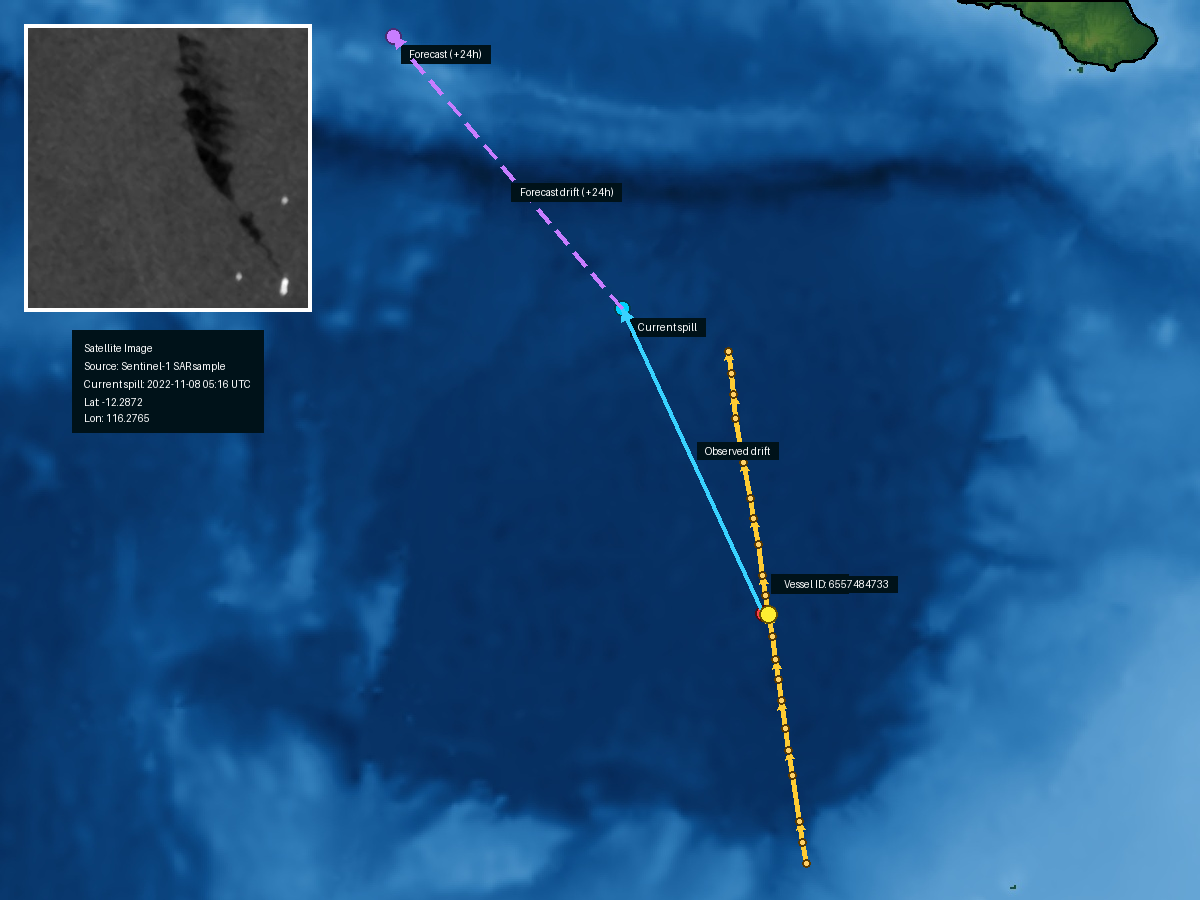

In [5]:
sample_records = load_sample_records()
if not EARTH_ENGINE_AVAILABLE and EE_INIT_ERROR == 'Earth Engine not initialized.':
    initialize_earth_engine()
rng = random.Random() if EARTH_ENGINE_AVAILABLE else random.Random(RANDOM_SELECTION_SEED)

# Keep live runs random, but force a positive sample in fallback mode so the demo stays populated.
forced_sample_label = FALLBACK_SAMPLE_LABEL if not EARTH_ENGINE_AVAILABLE else None
selected_record = choose_sample_record(sample_records, forced_label=forced_sample_label)
predicted_has_oil, oil_prob = predict_oil(selected_record['image_path'])

# Skip drift and vessel analysis entirely when the classifier predicts no spill.
decision = generate_scenario() if predicted_has_oil else build_no_spill_decision_info()

# Consolidate all per-case facts into one payload for map rendering and Gemma prompt generation.
case_payload = {
    'case_name': 'sample_case_01',
    'filename': selected_record['filename'],
    'image_path': selected_record['image_path'],
    'sample_satellite_source': SAMPLE_SATELLITE_SOURCE,
    'true_label': selected_record['true_label'],
    'gee_available': bool(EARTH_ENGINE_AVAILABLE),
    'demo_case_used': decision['scenario_status'] == 'demo_fallback',
    'live_scenario_generated': decision['scenario_status'] == 'ok',
    'predicted_label': int(predicted_has_oil),
    'oil_prob': oil_prob,
    'output_mode': ('classification_only' if not predicted_has_oil else ('live_2022_scenario' if decision['scenario_status'] == 'ok' else 'demo_fallback' if decision['scenario_status'] == 'demo_fallback' else 'scenario_failed')),
    'gee_status_note': ('Earth Engine was available for live scenario generation.' if EARTH_ENGINE_AVAILABLE else sanitize_fallback_reason(EE_INIT_ERROR)),
    'scenario_status': decision['scenario_status'],
    'ais_status': decision['ais_status'],
    'ais_note': decision['ais_note'],
    'current_lon': decision['current_lon'],
    'current_lat': decision['current_lat'],
    'current_timestamp': decision['current_timestamp'],
    'origin_lon': decision['origin_lon'],
    'origin_lat': decision['origin_lat'],
    'origin_timestamp': decision['origin_timestamp'],
    'forecast_lon': decision['forecast_lon'],
    'forecast_lat': decision['forecast_lat'],
    'forecast_timestamp': decision['forecast_timestamp'],
    'current_distance_to_coast_nm': decision['current_distance_nm'],
    'forecast_distance_to_coast_nm': decision['forecast_distance_nm'],
    'current_priority_high': decision['is_risk'],
    'forecast_priority_high': decision['forecast_is_risk'],
    'forecast_becomes_high_priority': decision['forecast_becomes_high_priority'],
    'origin_to_current_intersects_coast': decision['origin_to_current_intersects_coast'],
    'current_to_forecast_intersects_coast': decision['current_to_forecast_intersects_coast'],
    'priority_threshold_nm': decision['threshold'],
    'has_tanker_candidate': decision['has_tanker'],
}
case_vessels = [{'case_name': case_payload['case_name'], **vessel} for vessel in decision['vessels']]
gemma4_prompt = build_gemma4_prompt(case_payload, case_vessels)

# Render the full regional context only when the classifier predicts a spill; otherwise
# show the selected satellite chip by itself so cls_0 behavior stays easy to review.
if predicted_has_oil:
    overlay_image = render_case_region_overlay(
        output_path=None,
        case_row=case_payload,
        vessel_rows=case_vessels,
        coastline_gdf=coastline_gdf,
        region_bbox=REGION_BBOX,
        earth_engine_available=EARTH_ENGINE_AVAILABLE,
        ee_module=ee,
        ocean_validation_image_id=OCEAN_VALIDATION_IMAGE_ID,
        sample_image_path=case_payload.get('image_path'),
    )
else:
    overlay_image = Image.open(case_payload['image_path']).convert('RGB')

display(overlay_image)

In [6]:
# The final executive summary by Gemma4 combines the scenario facts, spill context, and vessel information into a concise text report that can be reviewed alongside the map overlay. This step demonstrates how the structured case payload can be used to generate human-friendly summaries for decision support.
executive_summary_markdown = generate_executive_summary_markdown(case_payload, case_vessels)
display(Markdown(executive_summary_markdown))

## Executive Summary

Google Earth Engine was available and this result is a live synthetic 2022 scenario. The classifier detected oil with a probability of 0.9976, indicating a spill is present. The current slick is positioned at -12.28719021866462, 116.276510439415 as of 2022-11-08T05:16:46+00:00, with an inferred origin at -14.817409406591317, 117.48390204408614 on 2022-11-07T05:16:46+00:00. The 24-hour forecast places the slick at -10.020858921503283, 114.31847076473453. Coastline exposure is currently 194.80 nm and is forecast to be 75.55 nm; coastline intersection does not drive priority as neither current nor forecast positions exceed the 12.0 nm priority threshold.

The top-ranked vessel is craft ID 6557484733, located 2.40 nm from the inferred origin. Vessel ranking was performed on 25 candidates from AMSA archives using a heuristic weighting time proximity and distance to origin, with speed and course as tie-breakers. Data is sourced from Sentinel-1 SAR samples, AMSA monthly AIS archives (including December 2021 and January 2023 for year-boundary context), HYCOM sea water velocity, and NOAA/NGDC ETOPO1 and Natural Earth coastline data via Google Earth Engine.

### Responder Takeaway

* **Slick Status:** Oil detected; current distance to coast is 194.80 nm, decreasing to 75.55 nm over the next 24 hours.
* **Priority:** Low; no current or forecast coastline intersections exceed the 12.0 nm threshold.
* **Primary Vessel of Interest:** Craft ID 6557484733 (ranked via proximity and time to inferred origin).
* **Data Provenance:** Analysis utilizes Sentinel-1 SAR, AMSA AIS archives, and HYCOM/NOAA data via Google Earth Engine.